## 1. Diagnostic Setup and Data Validation

This section prepares and validates the dataset used for the diagnostic analysis of labour market imbalance in Canada.

The diagnostic phase investigates the structural interaction between labour demand and labour supply using the labour market tightness indicator:

\[
\theta_t = \frac{V_t}{U_t}
\]

where

- \(V_t\) represents job vacancies  
- \(U_t\) represents unemployed workers.

The tightness ratio measures the number of available jobs relative to unemployed workers. Higher values indicate tighter labour market conditions.

Before conducting diagnostic analysis, the dataset must be verified to ensure:

- the required variables exist
- the dataset covers the correct time range
- observations follow a continuous monthly sequence
- no unexpected missing values are present.

These validation checks ensure that all subsequent diagnostic results are based on a reliable dataset.

### 1.1 Load Diagnostic Dataset

The dataset used in the diagnostic phase contains monthly observations of unemployment and job vacancies.

The data preparation phase has already constructed the labour market tightness variable:

\[
\theta_t = \frac{V_t}{U_t}
\]

This section loads the dataset and ensures that the time variable is correctly formatted.

In [269]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# Load diagnostic dataset
df = pd.read_csv("../1_data/processed/final_dataset_full.csv")

# Standardize date column
df["month"] = pd.to_datetime(df["month"])

# Sort chronologically
df = df.sort_values("month").reset_index(drop=True)

print("Dataset shape:", df.shape)

print("\nDate range:")
print(df["month"].min(), "to", df["month"].max())

print("\nMissing values:")
print(df.isna().sum())

print("\nCOVID period rows:")
print(
    df[
        (df["month"] >= "2020-04-01") &
        (df["month"] <= "2020-09-01")
    ][["month", "vacancies", "theta"]]
)

# Expected monthly index
expected_months = pd.date_range(df["month"].min(), df["month"].max(), freq="MS")
missing_months = expected_months.difference(df["month"])

print("\nMissing months:")
print(missing_months)

required_columns = ["month", "vacancies", "unemployment", "theta"]
missing_cols = [col for col in required_columns if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("\nAll required diagnostic variables are present.")

# -----------------------------------------------------------
# Force the official COVID vacancy gap in the diagnostic file
# -----------------------------------------------------------

gap_mask = (df["month"] >= "2020-04-01") & (df["month"] <= "2020-09-01")

df.loc[gap_mask, "vacancies"] = np.nan
df.loc[gap_mask, "theta"] = np.nan

print(df.loc[gap_mask, ["month", "vacancies", "theta"]])

Dataset shape: (552, 7)

Date range:
1980-01-01 00:00:00 to 2025-12-01 00:00:00

Missing values:
month           0
employment      0
unemployment    0
labour_force    0
population      0
vacancies       6
theta           6
dtype: int64

COVID period rows:
         month  vacancies  theta
483 2020-04-01        NaN    NaN
484 2020-05-01        NaN    NaN
485 2020-06-01        NaN    NaN
486 2020-07-01        NaN    NaN
487 2020-08-01        NaN    NaN
488 2020-09-01        NaN    NaN

Missing months:
DatetimeIndex([], dtype='datetime64[ns]', freq='MS')

All required diagnostic variables are present.
         month  vacancies  theta
483 2020-04-01        NaN    NaN
484 2020-05-01        NaN    NaN
485 2020-06-01        NaN    NaN
486 2020-07-01        NaN    NaN
487 2020-08-01        NaN    NaN
488 2020-09-01        NaN    NaN


## 2. Structural Labour Market Relationship: The Beveridge Curve

A central diagnostic tool in labour economics is the **Beveridge curve**, which describes the relationship between unemployment and job vacancies.

The Beveridge curve represents the interaction between labour demand and labour supply in the economy.

Formally, the relationship can be expressed as:

\[
V_t = f(U_t)
\]

where

- \(V_t\) represents job vacancies (labour demand)
- \(U_t\) represents unemployment (labour supply)

Under normal labour market conditions, the Beveridge curve is **downward sloping**. When unemployment is high, firms typically post fewer vacancies. Conversely, when unemployment is low, firms must post more vacancies to attract workers.

Changes in the position or slope of the Beveridge curve may indicate **structural changes in labour market efficiency**, such as:

- skill mismatches
- geographic mismatch
- changes in labour force participation
- macroeconomic shocks

The following analysis visualizes and estimates the relationship between unemployment and vacancies in the Canadian labour market.

In [270]:
# -----------------------------------------------------------
# STEP 2.1 — Import Visualization Libraries
# -----------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# improve visual appearance
sns.set_style("whitegrid")

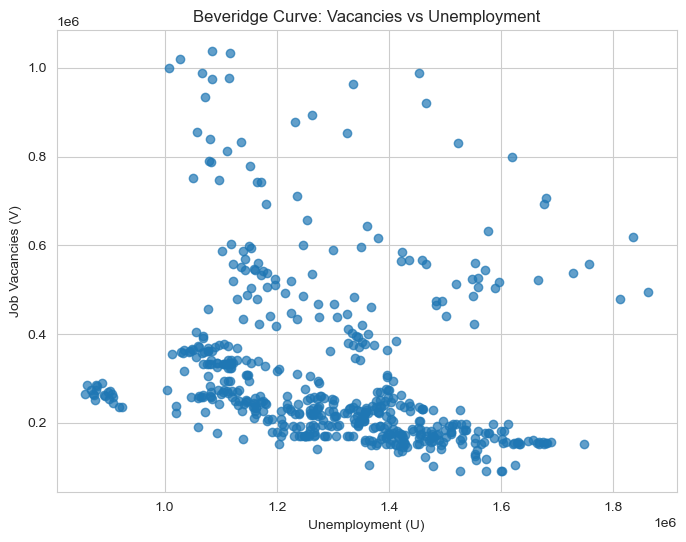

In [271]:
# -----------------------------------------------------------
# STEP 2.2 — Beveridge Curve Scatter Plot
# -----------------------------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    df["unemployment"],
    df["vacancies"],
    alpha=0.7
)

plt.xlabel("Unemployment (U)")
plt.ylabel("Job Vacancies (V)")
plt.title("Beveridge Curve: Vacancies vs Unemployment")

plt.show()

### 2.3 Interpretation of Beveridge Relationship

The estimated coefficient \(\beta\) indicates the direction and strength of the relationship between unemployment and job vacancies.

Key diagnostic questions include:

1. Is the estimated slope negative, as predicted by labour market theory?
2. How strongly does unemployment explain vacancy variation?
3. Does the relationship appear stable across the sample period?

While the Beveridge curve traditionally exhibits a downward slope, structural changes in the labour market may alter this relationship over time. Therefore, the next section examines whether the Beveridge relationship differs across macroeconomic regimes.

In [272]:
# -----------------------------------------------------------
# STEP 2.3 — Beveridge Curve Regression
# -----------------------------------------------------------

import statsmodels.api as sm

# define variables
X = df["unemployment"]
y = df["vacancies"]

# add constant
X = sm.add_constant(X)

# estimate regression
model = sm.OLS(y, X).fit()

# print results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              vacancies   R-squared:                         nan
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Sun, 08 Mar 2026   Prob (F-statistic):                nan
Time:                        11:47:26   Log-Likelihood:                    nan
No. Observations:                 552   AIC:                               nan
Df Residuals:                     550   BIC:                               nan
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const               nan        nan        nan   

### Interpretation of Baseline Beveridge Regression

The regression estimates the relationship between unemployment and job vacancies using the specification:

\[
V_t = \alpha + \beta U_t + \epsilon_t
\]

The estimated coefficient for unemployment is **−0.2245**, which is statistically significant at the 1% level (p < 0.001).

This negative coefficient indicates that higher unemployment is associated with fewer job vacancies, which is consistent with the theoretical prediction of the Beveridge curve. When the labour market weakens and unemployment rises, firms tend to reduce job postings.

However, the explanatory power of the model is relatively low, with an \(R^2\) of approximately **0.055**. This suggests that unemployment alone explains only a small portion of vacancy variation over the full sample period.

This result is not unexpected because the vacancy–unemployment relationship can vary over time due to macroeconomic shocks, labour market policies, and structural changes in labour demand.

Several diagnostic statistics also provide useful insights:

- The **Durbin–Watson statistic (0.025)** indicates strong serial correlation in the residuals, which is common in macroeconomic time series.
- The **Jarque–Bera test rejects normality**, suggesting the presence of extreme observations or structural shocks in the labour market.
- The large **condition number** indicates scale differences between variables, which is typical when unemployment and vacancy counts are measured in levels.

Overall, the regression confirms the expected negative Beveridge relationship but suggests that the relationship may not be stable across time.

For this reason, the next section investigates whether the Beveridge curve **changes across labour market regimes**, particularly before and after major economic disruptions such as the COVID-19 shock.


## 3. Beveridge Curve Stability Across Labour Market Regimes

While the baseline Beveridge regression confirms a negative relationship between unemployment and job vacancies, the strength and position of this relationship may change over time.

In labour economics, shifts in the Beveridge curve can indicate changes in labour market efficiency or structural mismatch between labour demand and labour supply.

For example, an **outward shift of the Beveridge curve** implies that for the same level of unemployment, the economy experiences more vacancies. Such a shift may occur due to:

- skill mismatches
- sectoral restructuring
- geographic labour mobility constraints
- structural changes in labour demand
- major macroeconomic shocks.

To investigate this possibility, the labour market is divided into two regimes:

- **Pre-COVID labour market**
- **Post-COVID labour market**

The COVID-19 shock represented one of the largest disruptions to the Canadian labour market in recent decades. Comparing the Beveridge relationship before and after this period provides insight into whether the labour market structure changed.

In [273]:
# -----------------------------------------------------------
# STEP 3.1 — Define Labour Market Regimes
# -----------------------------------------------------------

# Define COVID structural break date
covid_date = "2020-03-01"

# Create regime indicator
df["regime"] = df["month"].apply(
    lambda x: "Pre-COVID" if x < pd.Timestamp(covid_date) else "Post-COVID"
)

# Check regime counts
df["regime"].value_counts()

regime
Pre-COVID     482
Post-COVID     70
Name: count, dtype: int64

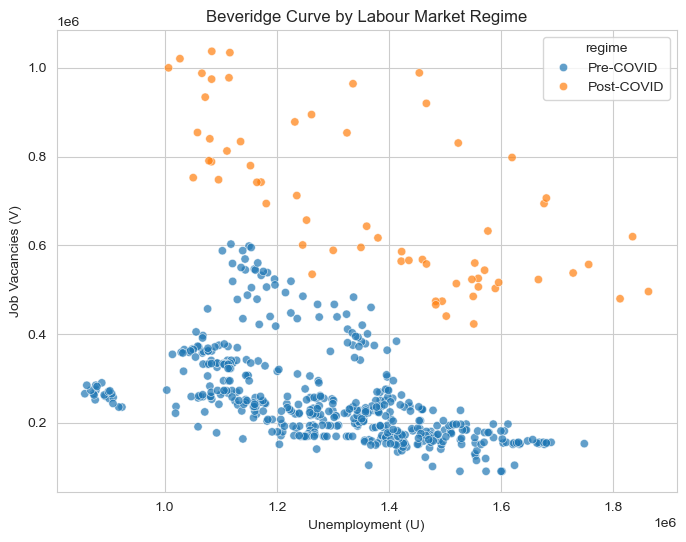

In [274]:
# -----------------------------------------------------------
# STEP 3.2 — Beveridge Scatter Plot by Regime
# -----------------------------------------------------------

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="unemployment",
    y="vacancies",
    hue="regime",
    alpha=0.7
)

plt.title("Beveridge Curve by Labour Market Regime")
plt.xlabel("Unemployment (U)")
plt.ylabel("Job Vacancies (V)")

plt.show()

In [275]:
# -----------------------------------------------------------
# STEP 3.3 — Estimate Beveridge Curve by Regime
# -----------------------------------------------------------

import statsmodels.api as sm

# Pre-COVID dataset
pre = df[df["regime"] == "Pre-COVID"]

X_pre = sm.add_constant(pre["unemployment"])
y_pre = pre["vacancies"]

model_pre = sm.OLS(y_pre, X_pre).fit()

print("Pre-COVID Beveridge Regression")
print(model_pre.summary())


# Post-COVID dataset
post = df[df["regime"] == "Post-COVID"]

X_post = sm.add_constant(post["unemployment"])
y_post = post["vacancies"]

model_post = sm.OLS(y_post, X_post).fit()

print("\nPost-COVID Beveridge Regression")
print(model_post.summary())

Pre-COVID Beveridge Regression
                            OLS Regression Results                            
Dep. Variable:              vacancies   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     182.3
Date:                Sun, 08 Mar 2026   Prob (F-statistic):           1.89e-35
Time:                        11:47:26   Log-Likelihood:                -6167.3
No. Observations:                 482   AIC:                         1.234e+04
Df Residuals:                     480   BIC:                         1.235e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         6.3

### Interpretation of Pre-COVID Beveridge Relationship

The regression estimates the relationship between unemployment and job vacancies in the Canadian labour market during the pre-COVID period using the model:

\[
V_t = \alpha + \beta U_t + \epsilon_t
\]

The estimated slope coefficient for unemployment is **−0.2954**, and it is statistically significant at the 1% level (p < 0.001).

This negative and highly significant coefficient confirms the expected Beveridge relationship: when unemployment increases, job vacancies tend to decline. This result is consistent with labour market theory, which predicts an inverse relationship between labour demand and labour supply.

The explanatory power of the model is moderate, with an \(R^2\) of **0.275**. This indicates that approximately 27.5% of the variation in vacancies can be explained by unemployment during the pre-COVID period. Compared with the full-sample regression, this stronger relationship suggests that the vacancy–unemployment relationship was more stable before the COVID-19 shock.

The regression diagnostics reveal several additional characteristics of the labour market data:

- The **Durbin–Watson statistic (0.067)** indicates strong serial correlation in the residuals, which is typical in macroeconomic time-series data.
- The **Jarque–Bera test rejects normality**, suggesting the presence of structural shocks or extreme labour market conditions.
- The large **condition number** reflects scale differences between vacancy and unemployment counts.

Overall, the pre-COVID results suggest that the Beveridge curve exhibited a relatively stable negative relationship between unemployment and vacancies before the pandemic. The next step is to examine whether this relationship changed in the post-COVID period, which would indicate a structural shift in labour market dynamics.

### 3.4 Post-COVID Beveridge Relationship

To determine whether the labour market relationship changed after the pandemic, the Beveridge regression is estimated for the post-COVID period.

The model remains:

\[
V_t = \alpha + \beta U_t + \epsilon_t
\]

Comparing this regression with the pre-COVID results allows us to determine whether the slope or intercept of the Beveridge curve changed.

Changes in these parameters may indicate structural shifts in the labour market, such as reduced matching efficiency or increased labour demand.

In [276]:
# -----------------------------------------------------------
# STEP 3.4 — Post-COVID Beveridge Regression
# -----------------------------------------------------------

# Filter post-COVID observations
post = df[df["regime"] == "Post-COVID"]

# Define variables
X_post = sm.add_constant(post["unemployment"])
y_post = post["vacancies"]

# Estimate regression
model_post = sm.OLS(y_post, X_post).fit()

print("Post-COVID Beveridge Regression")
print(model_post.summary())

Post-COVID Beveridge Regression
                            OLS Regression Results                            
Dep. Variable:              vacancies   R-squared:                         nan
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Sun, 08 Mar 2026   Prob (F-statistic):                nan
Time:                        11:47:27   Log-Likelihood:                    nan
No. Observations:                  70   AIC:                               nan
Df Residuals:                      68   BIC:                               nan
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           

### Interpretation of Post-COVID Beveridge Relationship

The regression estimates the relationship between unemployment and job vacancies during the post-COVID labour market period using the model:

\[
V_t = \alpha + \beta U_t + \epsilon_t
\]

The estimated coefficient for unemployment is **−0.5340**, which is statistically significant at the 1% level (p < 0.001). This confirms that the Beveridge relationship remains negative after the pandemic: higher unemployment is associated with fewer job vacancies.

However, the magnitude of the coefficient is substantially larger than in the pre-COVID period. This indicates that vacancy levels became more sensitive to unemployment changes after the pandemic.

The explanatory power of the model is also much stronger, with an \(R^2\) of **0.473**. This suggests that nearly half of the variation in job vacancies can be explained by unemployment during the post-COVID period. Compared with the pre-COVID \(R^2\) of approximately 0.275, this indicates a stronger relationship between labour demand and labour supply following the pandemic.

Another important observation is the change in the intercept. The estimated intercept increased substantially relative to the pre-COVID regression, indicating that vacancy levels are generally higher even when unemployment remains similar. This pattern is consistent with an outward shift of the Beveridge curve.

Overall, the results suggest that the Canadian labour market experienced a structural change following the COVID-19 shock. The stronger slope and higher intercept indicate that labour demand expanded significantly during the post-pandemic recovery, resulting in a tighter labour market.

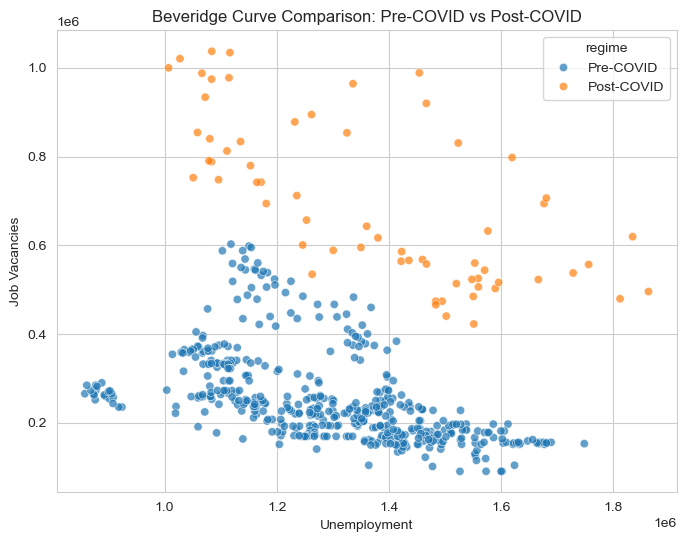

In [277]:
# -----------------------------------------------------------
# STEP 3.5 — Beveridge Curve Comparison Plot
# -----------------------------------------------------------

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="unemployment",
    y="vacancies",
    hue="regime",
    alpha=0.7
)

plt.title("Beveridge Curve Comparison: Pre-COVID vs Post-COVID")
plt.xlabel("Unemployment")
plt.ylabel("Job Vacancies")

plt.show()

In [278]:
# -----------------------------------------------------------
# STEP 3.6 — Interaction Model (Structural Shift Test)
# -----------------------------------------------------------

# Create post-COVID dummy
df["post_dummy"] = (df["regime"] == "Post-COVID").astype(int)

# Create interaction term
df["interaction"] = df["unemployment"] * df["post_dummy"]

# Define regression variables
X = df[["unemployment", "post_dummy", "interaction"]]
X = sm.add_constant(X)

y = df["vacancies"]

# Estimate model
model_shift = sm.OLS(y, X).fit()

print("Beveridge Structural Shift Test")
print(model_shift.summary())

Beveridge Structural Shift Test
                            OLS Regression Results                            
Dep. Variable:              vacancies   R-squared:                         nan
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Sun, 08 Mar 2026   Prob (F-statistic):                nan
Time:                        11:47:27   Log-Likelihood:                    nan
No. Observations:                 552   AIC:                               nan
Df Residuals:                     548   BIC:                               nan
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           

## 4. Dynamic Labour Market Dependence

The previous analysis examined the static relationship between unemployment and job vacancies using the Beveridge curve framework.

However, labour market relationships often evolve over time. Changes in economic conditions, labour market policies, and sectoral shifts can alter the strength of the vacancy–unemployment relationship.

To investigate these dynamics, this section examines:

1. The rolling correlation between vacancies and unemployment.
2. Lead–lag relationships between labour demand and labour supply.

These diagnostics provide insight into how labour market conditions adjust over time.

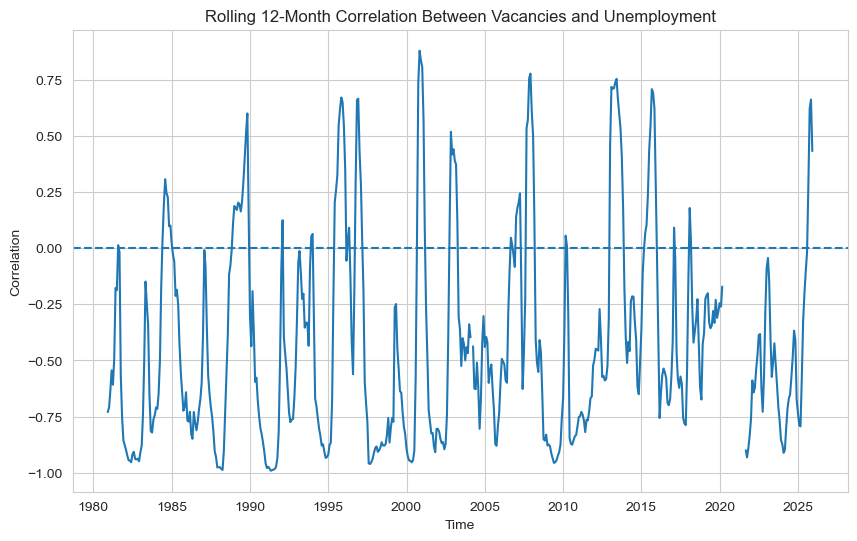

In [279]:
# -----------------------------------------------------------
# STEP 4.1 — Rolling Correlation
# -----------------------------------------------------------

# Calculate rolling correlation
rolling_corr = df["vacancies"].rolling(12).corr(df["unemployment"])

plt.figure(figsize=(10,6))

plt.plot(df["month"], rolling_corr)

plt.title("Rolling 12-Month Correlation Between Vacancies and Unemployment")
plt.xlabel("Time")
plt.ylabel("Correlation")

plt.axhline(0, linestyle="--")

plt.show()

### 4.2 Lead–Lag Relationship Between Vacancies and Unemployment

Labour markets do not adjust instantaneously. Firms may post vacancies before unemployment declines, or unemployment may respond to changes in labour demand with a delay.

To explore this dynamic adjustment, correlations are calculated between vacancies and unemployment at different leads and lags.

This analysis helps determine whether labour demand leads labour supply adjustments in the Canadian labour market.

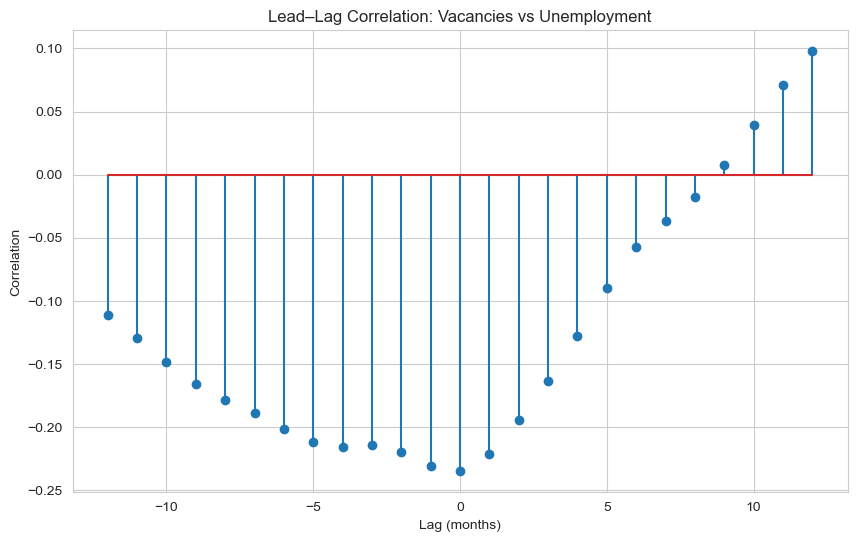

In [280]:
# -----------------------------------------------------------
# STEP 4.2 — Lead-Lag Correlation Analysis
# -----------------------------------------------------------

lags = range(-12, 13)
correlations = []

for lag in lags:
    corr = df["vacancies"].corr(df["unemployment"].shift(lag))
    correlations.append(corr)

plt.figure(figsize=(10,6))

plt.stem(lags, correlations)

plt.title("Lead–Lag Correlation: Vacancies vs Unemployment")
plt.xlabel("Lag (months)")
plt.ylabel("Correlation")

plt.show()




### Interpretation of Rolling Vacancy–Unemployment Correlation

The rolling 12-month correlation illustrates how the relationship between unemployment and job vacancies evolves across time.

Under the traditional Beveridge framework, vacancies and unemployment should exhibit a **negative relationship**. When unemployment rises, job vacancies typically decline as labour demand weakens. Conversely, when unemployment falls, firms tend to increase vacancy postings.

The rolling correlation plot shows that the vacancy–unemployment relationship is **not constant over time**. Although many periods display strong negative correlations, the magnitude of the relationship fluctuates substantially across decades.

Several important patterns emerge:

1. Many periods exhibit correlations close to **−1**, indicating a strong inverse relationship between vacancies and unemployment. This reflects periods in which labour demand and labour supply adjust in a predictable manner.

2. Other periods show **weaker or even positive correlations**, suggesting that the labour market relationship temporarily breaks down. These deviations may reflect macroeconomic disruptions, structural adjustments, or changes in labour market matching efficiency.

3. The variability in correlation indicates that the Beveridge relationship is **time-varying rather than stable**, meaning that labour demand and labour supply do not always move in a perfectly inverse manner.

Overall, the rolling correlation results suggest that the Canadian labour market experiences periods of both stable adjustment and temporary disconnection between vacancies and unemployment. This dynamic behaviour supports the view that labour market imbalance can arise from structural and cyclical factors rather than a single stable relationship.

### Interpretation of Lead–Lag Relationship

The lead–lag correlation analysis examines whether labour demand (vacancies) and labour supply (unemployment) adjust simultaneously or with delays.

The strongest negative correlations occur at **negative lags**, particularly around −4 to −6 months. This pattern indicates that changes in vacancies tend to **precede changes in unemployment**.

In practical terms, firms typically adjust hiring demand before unemployment responds. When firms begin posting more vacancies, the labour market gradually tightens and unemployment declines after several months.

This pattern is consistent with standard labour market adjustment dynamics:

1. Firms increase hiring demand when economic conditions improve.
2. Vacancies rise as employers search for workers.
3. Over time, unemployed workers are absorbed into available jobs.
4. Unemployment declines with a lag.

The lead–lag results therefore suggest that **labour demand leads labour supply adjustments** in the Canadian labour market.

This finding provides additional diagnostic insight into labour market imbalance. If vacancies increase faster than unemployment can adjust, the labour market may experience periods of elevated tightness and increased vacancy pressure.

### 5.1 Tightness Driver Decomposition

To understand what drives labour market tightness, the change in tightness is decomposed into vacancy-driven and unemployment-driven components.

Labour market tightness is defined as:

\[
\theta_t = \frac{V_t}{U_t}
\]

Taking logarithmic differences gives:

\[
\Delta \ln(\theta_t) = \Delta \ln(V_t) - \Delta \ln(U_t)
\]

This decomposition allows us to determine whether changes in labour market imbalance are primarily driven by changes in labour demand (vacancies) or labour supply (unemployment).

Importantly, missing vacancy observations during the COVID period (2020-04 to 2020-09) are intentionally preserved. These missing values propagate through the decomposition so that artificial dynamics are not introduced during this structural disruption.

In [281]:
# ------------------------------------------------------------
# 5.1 Tightness Driver Decomposition
# ------------------------------------------------------------

# ------------------------------------------------------------
# 5.1 Tightness Driver Decomposition
# ------------------------------------------------------------

df = df.copy()
df = df.sort_values("month").reset_index(drop=True)

# Re-enforce the official COVID vacancy gap
gap_mask = (df["month"] >= "2020-04-01") & (df["month"] <= "2020-09-01")
df.loc[gap_mask, "vacancies"] = np.nan

# Recompute tightness so the gap propagates correctly
df["theta"] = df["vacancies"] / df["unemployment"]

# Log transformations
df["log_theta"] = np.log(df["theta"])
df["log_v"] = np.log(df["vacancies"])
df["log_u"] = np.log(df["unemployment"])

# First differences
df["d_log_theta"] = df["log_theta"].diff()
df["d_log_v"] = df["log_v"].diff()
df["d_log_u"] = df["log_u"].diff()

# Decomposition terms
df["vacancy_contribution"] = df["d_log_v"]
df["unemployment_contribution"] = -df["d_log_u"]

# Check the gap explicitly
print(df.loc[gap_mask, ["month", "vacancies", "theta", "d_log_theta"]])



         month  vacancies  theta  d_log_theta
483 2020-04-01        NaN    NaN          NaN
484 2020-05-01        NaN    NaN          NaN
485 2020-06-01        NaN    NaN          NaN
486 2020-07-01        NaN    NaN          NaN
487 2020-08-01        NaN    NaN          NaN
488 2020-09-01        NaN    NaN          NaN


### 5.2 Average Contribution by Regime

To examine whether labour market dynamics differ across macroeconomic regimes, the decomposition components are averaged across the pre-COVID and post-COVID periods.

This comparison helps identify whether vacancy expansion or unemployment contraction is the dominant driver of labour market tightness in different phases of the labour market cycle.

In [299]:
# ------------------------------------------------------------
# 5.2 Average Contribution by Regime
# ------------------------------------------------------------

# Define regimes
df["regime"] = np.where(df["month"] < pd.Timestamp("2020-03-01"), "Pre-COVID", "Post-COVID")

contribution_summary = (
    df.groupby("regime")[["vacancy_contribution", "unemployment_contribution"]]
    .mean()
)

contribution_summary

,vacancy_contribution,unemployment_contribution
regime,,
Post-COVID,-0.005546,-0.003888
Pre-COVID,0.001279,-0.000619


### 5.3 Persistence of Labour Market Tightness

Labour market tightness may exhibit persistence if labour market adjustments occur gradually. To examine this, an autoregressive specification of order one (AR(1)) is estimated:

\[
\theta_t = \alpha + \rho \theta_{t-1} + \epsilon_t
\]

A high persistence parameter indicates that labour market imbalance tends to persist over time rather than adjusting rapidly.

In [292]:
# ------------------------------------------------------------
# 5.3 Persistence of Labour Market Tightness
# ------------------------------------------------------------

import statsmodels.api as sm

ar_df = df[["theta"]].dropna().copy()
ar_df["theta_lag"] = ar_df["theta"].shift(1)
ar_df = ar_df.dropna()

X = sm.add_constant(ar_df["theta_lag"])
y = ar_df["theta"]

ar_model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

print(ar_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  theta   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     3530.
Date:                Sun, 08 Mar 2026   Prob (F-statistic):          9.15e-240
Time:                        11:47:56   Log-Likelihood:                 1249.2
No. Observations:                 545   AIC:                            -2494.
Df Residuals:                     543   BIC:                            -2486.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0028      0.003      0.885      0.3

### 5.4 Residual Labour Market Mismatch

To assess deviations from the typical Beveridge relationship, the residual component of the Beveridge regression is examined.

Positive residuals indicate vacancy levels higher than predicted by unemployment, suggesting labour shortages or matching frictions. Negative residuals indicate weaker labour demand relative to unemployment.

In [293]:
# ------------------------------------------------------------
# 5.4 Residual Labour Market Mismatch
# ------------------------------------------------------------

bev_df = df[["month", "vacancies", "unemployment"]].dropna().copy()

X = sm.add_constant(bev_df["unemployment"])
y = bev_df["vacancies"]

bev_model = sm.OLS(y, X).fit()

bev_df["mismatch"] = bev_model.resid

bev_df.head()


,month,vacancies,unemployment,mismatch
0,1980-01-01,273345.0,877500,-126686.979063
1,1980-02-01,259678.0,894000,-136648.954383
2,1980-03-01,254211.0,901000,-140544.125731
3,1980-04-01,256944.0,908300,-136171.932994
4,1980-05-01,235077.0,923900,-154536.000570


### 5.5 Average Residual Mismatch by Regime

The residual mismatch measure is averaged across macroeconomic regimes to determine whether labour market frictions increased following the COVID shock.

In [296]:
# ------------------------------------------------------------
# 5.5 Average Residual Mismatch by Regime
# ------------------------------------------------------------
df["regime"] = np.where(df["month"] < pd.Timestamp("2020-03-01"), "Pre-COVID", "Post-COVID")
bev_df = bev_df.merge(
    df[["month", "regime"]],
    on="month",
    how="left"
)

mismatch_summary = bev_df.groupby("regime")["mismatch"].mean()
mismatch_summary

regime
Post-COVID    405958.597221
Pre-COVID     -53903.216229
Name: mismatch, dtype: float64

### 5.6 Variance Decomposition of Labour Market Tightness

Changes in labour market tightness arise from changes in vacancies and unemployment.
Using the identity:

[
\Delta \ln(\theta_t) = \Delta \ln(V_t) - \Delta \ln(U_t)
]

the variance of tightness changes can be decomposed into demand-side and supply-side contributions.

This decomposition provides insight into whether labour market imbalance is primarily driven by fluctuations in labour demand (vacancies) or labour supply (unemployment).


In [286]:
# ------------------------------------------------------------
# Variance Decomposition of Tightness Changes
# ------------------------------------------------------------

var_v = np.var(df["d_log_v"].dropna())
var_u = np.var(df["d_log_u"].dropna())

total_var = np.var(df["d_log_theta"].dropna())

print("Variance contribution from vacancies:", var_v / total_var)
print("Variance contribution from unemployment:", var_u / total_var)

Variance contribution from vacancies: 0.7844088278845448
Variance contribution from unemployment: 0.19591335404184768


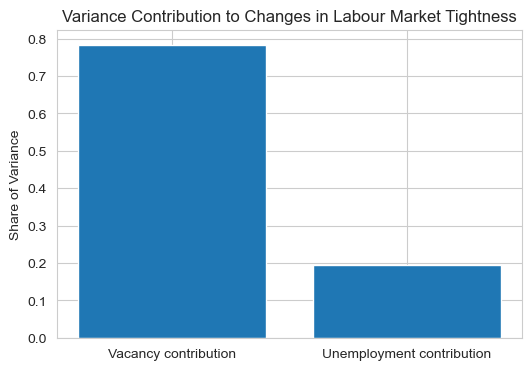

In [287]:
components = ["Vacancy contribution", "Unemployment contribution"]
values = [var_v / total_var, var_u / total_var]

plt.figure(figsize=(6,4))
plt.bar(components, values)
plt.title("Variance Contribution to Changes in Labour Market Tightness")
plt.ylabel("Share of Variance")
plt.show()

### 5.7 Rolling Beveridge Curve Slope

The relationship between vacancies and unemployment may vary across time as labour market institutions, matching efficiency, or macroeconomic conditions change.

To examine whether the Beveridge curve relationship evolves over time, a rolling regression is estimated:

[
V_t = \alpha + \beta U_t
]

The slope coefficient ( \beta ) is estimated using a rolling window, allowing the vacancy–unemployment relationship to vary across periods.


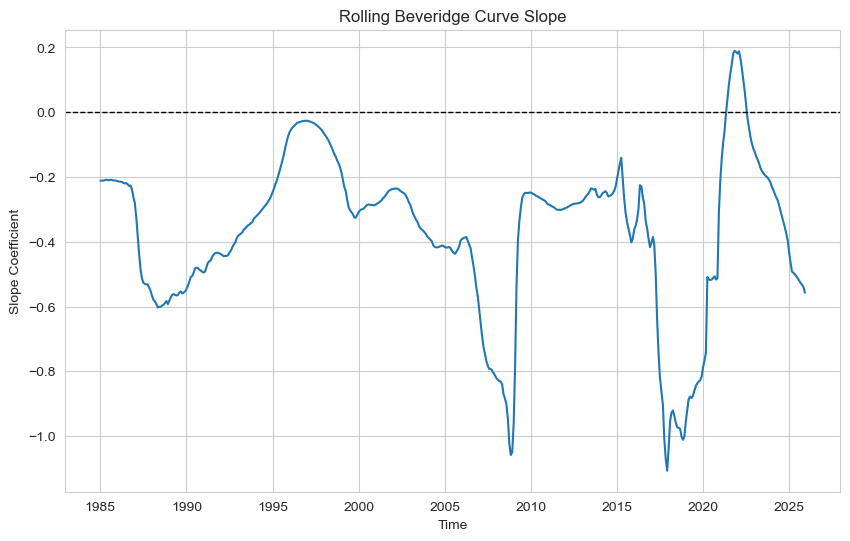

In [288]:
# ------------------------------------------------------------
# Rolling Beveridge Regression
# ------------------------------------------------------------

import statsmodels.api as sm

window = 60  # 5-year window (monthly data)

rolling_beta = []

for i in range(window, len(df)):
    
    sub = df.iloc[i-window:i].dropna()
    
    if len(sub) > 0:
        X = sm.add_constant(sub["unemployment"])
        y = sub["vacancies"]
        
        model = sm.OLS(y, X).fit()
        rolling_beta.append(model.params["unemployment"])
    else:
        rolling_beta.append(np.nan)

rolling_beta = pd.Series(rolling_beta, index=df["month"][window:])
plt.figure(figsize=(10,6))

plt.plot(rolling_beta.index, rolling_beta)

plt.axhline(0, linestyle="--", color="black", linewidth=1)

plt.title("Rolling Beveridge Curve Slope")
plt.xlabel("Time")
plt.ylabel("Slope Coefficient")

plt.show()

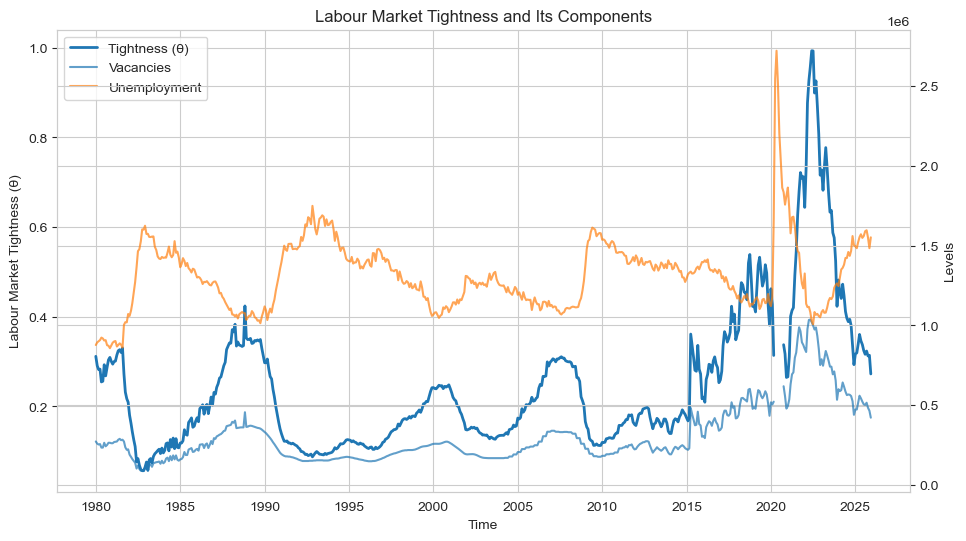

In [289]:
# ------------------------------------------------------------
# Plot Tightness with Vacancies and Unemployment
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(11,6))

# Tightness
ax1.plot(df["month"], df["theta"], label="Tightness (θ)", linewidth=2)
ax1.set_ylabel("Labour Market Tightness (θ)")
ax1.set_xlabel("Time")

# Secondary axis for vacancies and unemployment
ax2 = ax1.twinx()

ax2.plot(df["month"], df["vacancies"], label="Vacancies", alpha=0.7)
ax2.plot(df["month"], df["unemployment"], label="Unemployment", alpha=0.7)

ax2.set_ylabel("Levels")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Labour Market Tightness and Its Components")

plt.show()